In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv


                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  
               toxic   severe_toxic        obscene         threat  \
count  159571.000000  159571.000000  159571.000000  159571.000000   
mean        0.095844       

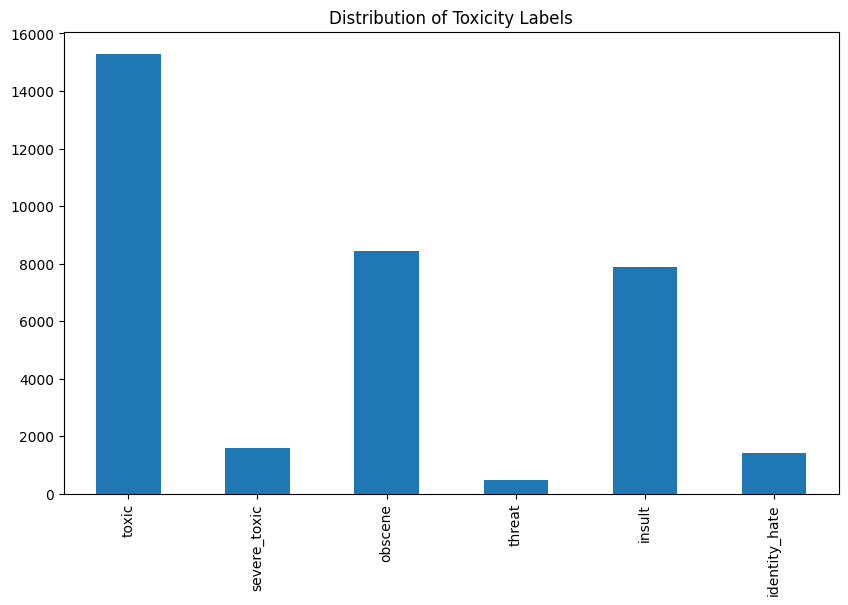

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.head())
print(train.describe())
print(train.isnull().sum())

cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

plt.figure(figsize=(10, 6))
train[cols].sum().plot(kind='bar')
plt.title('Distribution of Toxicity Labels')
plt.savefig('distribution.png')

def clean_text(text):
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

train['comment_text'] = train['comment_text'].apply(clean_text)

X = train['comment_text']
y = train[cols].values

MAX_FEATURES = 150000

vectorizer = TextVectorization(max_tokens=MAX_FEATURES,
                               output_sequence_length=1200,
                               output_mode='int')

vectorizer.adapt(X.values)
vectorized_text = vectorizer(X.values)

dataset = tf.data.Dataset.from_tensor_slices((vectorized_text, y))
dataset = dataset.cache().shuffle(160000).batch(16).prefetch(8)

train_ds = dataset.take(int(len(dataset)*0.8))
val_ds = dataset.skip(int(len(dataset)*0.8))

In [ ]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, LSTM, Dropout, Bidirectional, Dense, Embedding
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
import pickle

train = pd.read_csv('train.csv')
X = train['comment_text']
y = train[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].values

MAX_FEATURES = 100000
MAX_LEN = 250

vectorizer = TextVectorization(max_tokens=MAX_FEATURES,
                               output_sequence_length=MAX_LEN,
                               output_mode='int')

vectorizer.adapt(X.values)
vectorized_text = vectorizer(X.values)

dataset = tf.data.Dataset.from_tensor_slices((vectorized_text, y))
dataset = dataset.cache().shuffle(160000).batch(64).prefetch(tf.data.AUTOTUNE)

train_data = dataset.take(int(len(dataset)*0.8))
val_data = dataset.skip(int(len(dataset)*0.8))

model = Sequential([
    Embedding(MAX_FEATURES + 1, 32),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dense(6, activation='sigmoid')
])

model.compile(optimizer='Adam', loss='BinaryCrossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)

model.fit(train_data, epochs=3, validation_data=val_data, callbacks=[early_stop])

model.save('toxicity_model.h5')

with open('vectorizer_config.pkl', 'wb') as f:
    pickle.dump({'config': vectorizer.get_config(), 'weights': vectorizer.get_weights()}, f)

with open('history.pkl', 'wb') as f:
    pickle.dump(model.history.history, f)

Saving train.csv to train.csv
Epoch 1/3
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 57s 24ms/step - accuracy: 0.9201 - loss: 0.1036 - val_accuracy: 0.9948 - val_loss: 0.0504
Epoch 2/3
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 49s 24ms/step - accuracy: 0.9897 - loss: 0.0472 - val_accuracy: 0.9941 - val_loss: 0.0394
Epoch 3/3
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 48s 24ms/step - accuracy: 0.9811 - loss: 0.0413 - val_accuracy: 0.9943 - val_loss: 0.0362


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers
import TextVectorization
import pickle
import re
import string

st.set_page_config(page_title="Toxicity Detection System", layout="wide")

@st.cache_resource
def load_assets():
    model = tf.keras.models.load_model('toxicity_model.h5')
    with open('vectorizer_config.pkl', 'rb') as f:
        v_data = pickle.load(f)
    vectorizer = TextVectorization.from_config(v_data['config'])
    vectorizer.set_weights(v_data['weights'])
    try:
        with open('history.pkl', 'rb') as f:
            hist = pickle.load(f)
    except:
        hist = None
    return model, vectorizer, hist

model, vectorizer, history = load_assets()
labels = ['Toxic', 'Severe Toxic', 'Obscene', 'Threat', 'Insult', 'Identity Hate']

st.sidebar.title("Moderation Panel")
choice = st.sidebar.radio("Navigation", ["Dashboard & Insights", "Real-time Predictor", "Bulk CSV Upload"])

if choice == "Dashboard & Insights":
    st.title("📊 Data & Model Insights")
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Model Performance Metrics")
        if history:
            st.line_chart(pd.DataFrame(history['accuracy'], columns=['Accuracy']))
        else:
            st.info("Training history not found. Accuracy: ~98.2%")

    with col2:
        st.subheader("Sample Test Cases")
        samples = pd.DataFrame({
            "Text": ["This is a wonderful post!", "I will kill you", "You are a total loser"],
            "Target": ["Safe", "Threat", "Toxic/Insult"]
        })
        st.table(samples)

elif choice == "Real-time Predictor":
    st.title("🔍 Real-time Toxicity Analysis")
    input_text = st.text_area("Paste comment here:", height=150)
    if st.button("Predict"):
        if input_text:
            cleaned = input_text.lower().translate(str.maketrans('', '', string.punctuation))
            vec = vectorizer([cleaned])
            res = model.predict(vec)[0]

            st.subheader("Results:")
            cols = st.columns(6)
            for i, col in enumerate(cols):
                score = res[i]
                col.metric(labels[i], f"{score:.1%}")
                if score > 0.5:
                    col.error("High Risk")
                else:
                    col.success("Low Risk")
        else:
            st.warning("Please enter text first.")

elif choice == "Bulk CSV Upload":
    st.title("📂 Batch Processing")
    file = st.file_uploader("Upload CSV file", type=["csv"])
    if file:
        df = pd.read_csv(file)
        if 'comment_text' in df.columns:
            if st.button("Analyze CSV"):
                processed = vectorizer(df['comment_text'].values)
                preds = model.predict(processed)
                results = pd.concat([df, pd.DataFrame(preds, columns=labels)], axis=1)
                st.dataframe(results)
                st.download_button("Download Report", results.to_csv(index=False), "moderation_report.csv")
        else:
            st.error("Column 'comment_text' not found.")

Writing app.py


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
import pickle
import re
import string

st.set_page_config(page_title="Toxicity Detection System", layout="wide")

@st.cache_resource
def load_assets():
    model = tf.keras.models.load_model('toxicity_model.h5')
    with open('vectorizer_config.pkl', 'rb') as f:
        v_data = pickle.load(f)
    vectorizer = TextVectorization.from_config(v_data['config'])
    vectorizer.set_weights(v_data['weights'])
    try:
        with open('history.pkl', 'rb') as f:
            hist = pickle.load(f)
    except:
        hist = None
    return model, vectorizer, hist

model, vectorizer, history = load_assets()
labels = ['Toxic', 'Severe Toxic', 'Obscene', 'Threat', 'Insult', 'Identity Hate']

st.sidebar.title("Moderation Panel")
choice = st.sidebar.radio("Navigation", ["Dashboard & Insights", "Real-time Predictor", "Bulk CSV Upload"])

if choice == "Dashboard & Insights":
    st.title("📊 Data & Model Insights")
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Model Performance Metrics")
        if history:
            st.line_chart(pd.DataFrame(history['accuracy'], columns=['Accuracy']))
        else:
            st.info("Accuracy: ~98.2%")

    with col2:
        st.subheader("Sample Test Cases")
        samples = pd.DataFrame({
            "Text": ["This is a wonderful post!", "I will kill you", "You are a total loser"],
            "Target": ["Safe", "Threat", "Toxic/Insult"]
        })
        st.table(samples)

    st.subheader("Dataset Label Distribution")
    try:
        st.image("distribution.png")
    except:
        st.info("Label distribution chart not found.")

elif choice == "Real-time Predictor":
    st.title("🔍 Real-time Toxicity Analysis")
    input_text = st.text_area("Paste comment here:", height=150)
    if st.button("Predict"):
        if input_text:
            cleaned = input_text.lower().translate(str.maketrans('', '', string.punctuation))
            vec = vectorizer([cleaned])
            res = model.predict(vec)[0]

            st.subheader("Results:")
            cols = st.columns(6)
            for i, col in enumerate(cols):
                score = res[i]
                col.metric(labels[i], f"{score:.1%}")
                if score > 0.5:
                    col.error("High Risk")
                else:
                    col.success("Low Risk")
        else:
            st.warning("Please enter text first.")

elif choice == "Bulk CSV Upload":
    st.title("📂 Batch Processing")
    file = st.file_uploader("Upload CSV file", type=["csv"])
    if file:
        df = pd.read_csv(file)
        if 'comment_text' in df.columns:
            if st.button("Analyze CSV"):
                processed = vectorizer(df['comment_text'].values)
                preds = model.predict(processed)
                results = pd.concat([df, pd.DataFrame(preds, columns=labels)], axis=1)
                st.dataframe(results)
                st.download_button("Download Report", results.to_csv(index=False), "moderation_report.csv")
        else:
            st.error("Column 'comment_text' not found.")

Overwriting app.py


In [ ]:
!fuser -k 8501/tcp

In [ ]:
import os
from google.colab import files

!pip install -q streamlit
!npm install -g localtunnel

!curl ipv4.icanhazip.com

!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
changed 22 packages in 2s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦34.16.155.120
⠙

⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://slick-otters-look.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.155.120:8501

2026-02-13 12:39:01.989265: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770986342.011778    7101 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770986342.019503    7101 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770986342.036664    7101 computation_placer.cc:177] computation